# Trabalho Prático 02 - Clustering K-Means
### GCC 128 - Inteligência Artificial
**Professor:** Ahmed Ali Abdalla Esmin

**Aluno:** Tobias Maugus Bueno Cougo

---
Este notebook aplica o algoritmo **K-Means** (aprendizado não supervisionado) à
base de dados **Iris**, explorando como o número de clusters (**K**) afeta o
agrupamento, avaliando os resultados com **WCSS**, **Silhouette Score** e o
**Método do Cotovelo**, e comparando o efeito da **padronização** dos
atributos. Os rótulos reais das espécies são usados **apenas para análise e
comparação posterior**, nunca como entrada do algoritmo.

## 1. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

np.random.seed(42)


## 2. Carregamento da base de dados

Utilizamos novamente a base **Iris** (mesma do TP01), agora em um cenário de
**aprendizado não supervisionado**: o K-Means só recebe os 4 atributos
numéricos. Os rótulos de espécie (`y`) são guardados à parte e usados
**somente mais adiante**, para analisar o quanto os clusters encontrados se
aproximam das espécies reais — em nenhum momento eles entram no treinamento.

In [2]:
iris = load_iris()
X = iris.data                     # atributos - único dado usado pelo K-Means
y = iris.target                   # rótulos reais - usados só para análise posterior
feat_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feat_names)
df['species (apenas p/ referência)'] = [target_names[i] for i in y]

print(f"Formato da base: {X.shape[0]} amostras, {X.shape[1]} atributos")
df.head()


Formato da base: 150 amostras, 4 atributos


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species (apenas p/ referência)
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Análise exploratória rápida

Antes de agrupar, vale observar a escala de cada atributo. Note que
**comprimento da pétala** varia bem mais (maior variância) que **largura da
sépala**, por exemplo — isso é relevante porque o K-Means é baseado em
distância, então atributos com maior variância tendem a dominar o cálculo.

In [3]:
resumo = df.describe().round(2)
print(resumo)
print()
print("Variância de cada atributo (dados brutos):")
print(df[feat_names].var().round(3))


       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean                5.84              3.06               3.76              1.20
std                 0.83              0.44               1.77              0.76
min                 4.30              2.00               1.00              0.10
25%                 5.10              2.80               1.60              0.30
50%                 5.80              3.00               4.35              1.30
75%                 6.40              3.30               5.10              1.80
max                 7.90              4.40               6.90              2.50

Variância de cada atributo (dados brutos):
sepal length (cm)    0.686
sepal width (cm)     0.190
petal length (cm)    3.116
petal width (cm)     0.581
dtype: float64


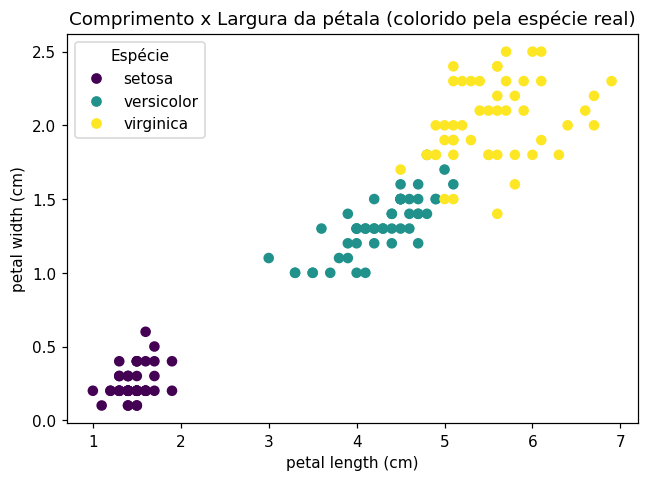

In [4]:
# Visualização exploratória (apenas contexto - a cor aqui vem da espécie real,
# NÃO de um agrupamento; serve só para mostrar que já existe separação natural
# nos atributos de pétala)
fig, ax = plt.subplots(figsize=(6, 4.5))
scatter = ax.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', s=35)
ax.set_xlabel(feat_names[2])
ax.set_ylabel(feat_names[3])
ax.set_title("Comprimento x Largura da pétala (colorido pela espécie real)")
handles, _ = scatter.legend_elements()
ax.legend(handles, target_names, title="Espécie")
plt.tight_layout()
plt.show()


## 4. Pré-processamento: padronização dos atributos

Como o K-Means agrupa com base na **distância Euclidiana**, atributos em
escalas diferentes podem ter peso desproporcional. A prática recomendada é
padronizar (`StandardScaler`, média 0 e desvio-padrão 1) antes de agrupar.
Aqui vamos manter **as duas versões** — dados brutos e padronizados — para
comparar o efeito da padronização mais adiante (Seção 8).

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Médias após padronização (devem ser ~0):", X_scaled.mean(axis=0).round(3))
print("Desvios após padronização (devem ser ~1):", X_scaled.std(axis=0).round(3))


Médias após padronização (devem ser ~0): [-0. -0. -0. -0.]
Desvios após padronização (devem ser ~1): [1. 1. 1. 1.]


## 5. Escolha do número de clusters (K)

### 5.1 Método do Cotovelo (Elbow Method)

O WCSS (*Within-Cluster Sum of Squares*, também chamado de inércia) mede o
quão compactos os clusters são — quanto menor, mais próximos os pontos estão
dos seus centróides. Ele sempre cai conforme K aumenta; o "cotovelo" (ponto
onde a curva para de cair tão rápido) sugere um bom valor de K.

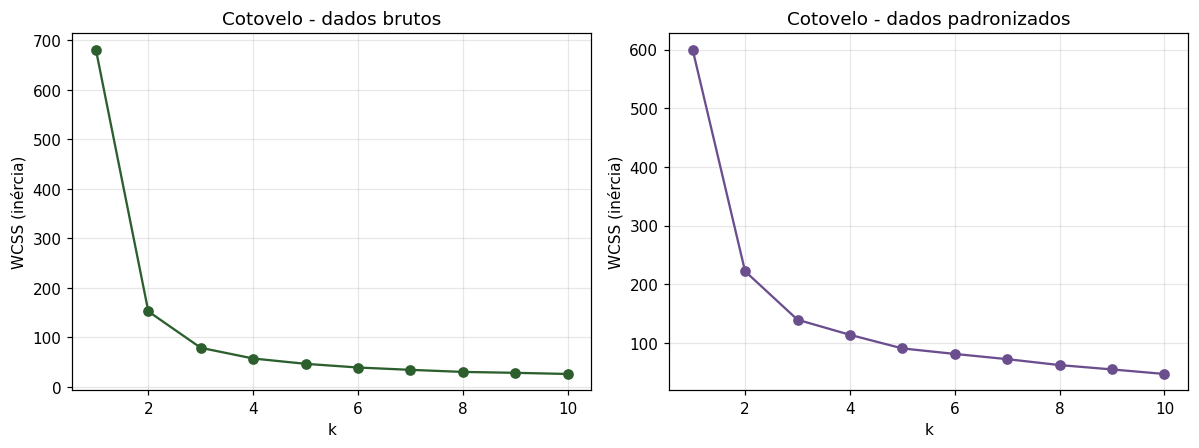

In [6]:
ks = list(range(1, 11))
wcss_raw, wcss_scaled = [], []

for k in ks:
    wcss_raw.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_)
    wcss_scaled.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(ks, wcss_raw, marker='o', color='#2C5F2D')
axes[0].set_title("Cotovelo - dados brutos")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS (inércia)")
axes[0].grid(alpha=0.3)

axes[1].plot(ks, wcss_scaled, marker='o', color='#6B4E8E')
axes[1].set_title("Cotovelo - dados padronizados")
axes[1].set_xlabel("k"); axes[1].set_ylabel("WCSS (inércia)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
tabela_wcss = pd.DataFrame({'k': ks, 'WCSS (bruto)': wcss_raw, 'WCSS (padronizado)': wcss_scaled}).round(2)
tabela_wcss


,k,WCSS (bruto),WCSS (padronizado)
0,1,681.37,600.00
1,2,152.35,222.36
2,3,78.85,139.82
3,4,57.23,114.09
4,5,46.46,90.93
5,6,39.04,81.54
6,7,34.31,72.63
7,8,30.13,62.54
8,9,28.29,55.12
9,10,25.97,47.39


Em ambos os casos, a curva "quebra" visivelmente entre **k=2 e k=3**, e
continua caindo de forma bem mais suave depois disso — um indício de que 2 ou
3 clusters já capturam a maior parte da estrutura dos dados.

### 5.2 Silhouette Score

O Silhouette mede, para cada ponto, o quão bem ele se encaixa no seu próprio
cluster comparado aos clusters vizinhos (varia de -1 a 1; quanto maior,
melhor definidos e mais separados estão os clusters).

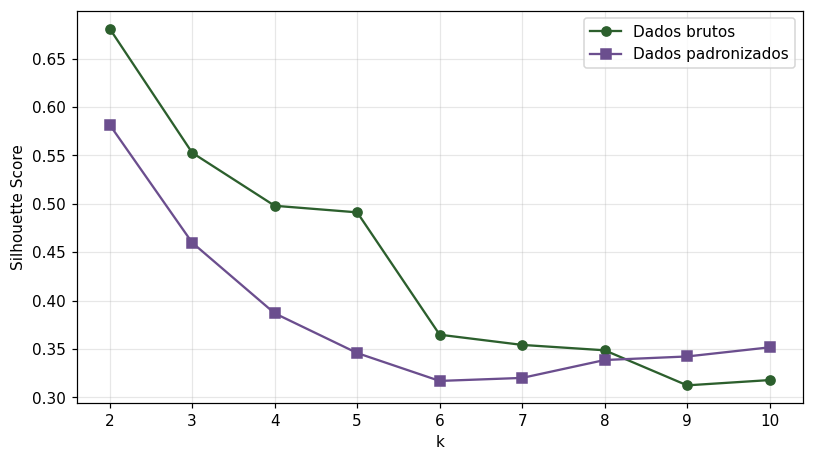

,k,Silhouette (bruto),Silhouette (padronizado)
0,2,0.681046,0.581750
1,3,0.552819,0.459948
2,4,0.498051,0.386941
3,5,0.491240,0.345901
4,6,0.364834,0.317079
5,7,0.354298,0.320197
6,8,0.348735,0.338692
7,9,0.312504,0.342360
8,10,0.317966,0.351793


In [8]:
ks_sil = list(range(2, 11))
sil_raw, sil_scaled = [], []

for k in ks_sil:
    labels_raw = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    labels_scaled = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sil_raw.append(silhouette_score(X, labels_raw))
    sil_scaled.append(silhouette_score(X_scaled, labels_scaled))

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(ks_sil, sil_raw, marker='o', label='Dados brutos', color='#2C5F2D')
ax.plot(ks_sil, sil_scaled, marker='s', label='Dados padronizados', color='#6B4E8E')
ax.set_xlabel("k"); ax.set_ylabel("Silhouette Score")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tabela_sil = pd.DataFrame({'k': ks_sil, 'Silhouette (bruto)': sil_raw, 'Silhouette (padronizado)': sil_scaled})
tabela_sil


O maior Silhouette Score, nos dois casos, ocorre em **k=2** — o que faz
sentido, já que a espécie *setosa* é claramente separada das outras duas, que
por sua vez se sobrepõem parcialmente. Ainda assim, **k=3** é o valor mais
coerente com o conhecimento de domínio (sabemos que existem 3 espécies) e
aparece logo em seguida como o segundo melhor valor de Silhouette, além de
ser exatamente o ponto de inflexão do cotovelo. Por isso, adotamos **k=3**
como principal valor de análise a partir daqui — sem descartar k=2 e k=4/5,
que exploramos na próxima seção para entender o efeito de K no resultado.

## 6. Efeito do valor de K nos agrupamentos

Para visualizar o efeito de K, reduzimos os 4 atributos a 2 dimensões com
**PCA** (Análise de Componentes Principais) e comparamos os agrupamentos
obtidos para K = 2, 3, 4 e 5.

Variância explicada pelas 2 componentes: 97.77%


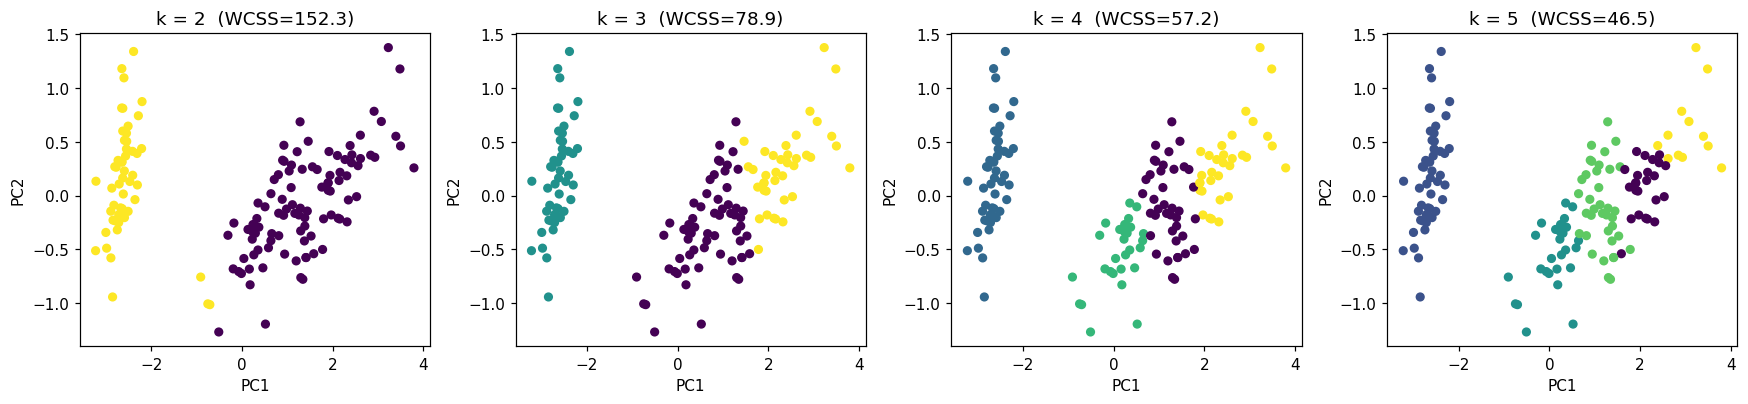

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, k in zip(axes, [2, 3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km.labels_, cmap='viridis', s=25)
    ax.set_title(f"k = {k}  (WCSS={km.inertia_:.1f})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()


Com **k=2**, o algoritmo separa *setosa* (bem isolada) do restante (
*versicolor* + *virginica* juntas em um só grupo). Com **k=3**, esse segundo
grande grupo se divide em dois, aproximando-se das espécies reais. Já com
**k=4** e **k=5**, os clusters adicionais aparecem **dentro** da região que
antes era um único grupo bem definido — ou seja, o algoritmo passa a
subdividir uma população naturalmente contínua (*versicolor*/*virginica* se
misturam) em fatias que não correspondem a nenhuma estrutura real adicional.
Isso ilustra bem por que o Método do Cotovelo e o Silhouette apontam K
pequeno (2 ou 3) como preferível para esta base.

## 7. Modelo final com K = 3

Seguimos com **k=3** nos dados **brutos** (a comparação com a versão
padronizada é feita na Seção 8).

In [10]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X)

wcss_final = kmeans_final.inertia_
sil_final = silhouette_score(X, labels)

print(f"WCSS (inércia):     {wcss_final:.2f}")
print(f"Silhouette Score:   {sil_final:.4f}")


WCSS (inércia):     78.85
Silhouette Score:   0.5528


### Comparação com as espécies reais (apenas para análise)

Os rótulos de cluster (0, 1, 2) são arbitrários — nada garante que o cluster
"0" corresponda à espécie de índice 0. Por isso, para exibir os dois lados
com **cores comparáveis nas próximas visualizações**, reordenamos os rótulos
de cluster de modo a casar cada cluster com a espécie majoritária dentro
dele (algoritmo húngaro / `linear_sum_assignment`). Essa reordenação é
**apenas cosmética**, usada exclusivamente para facilitar a leitura visual —
não altera o agrupamento em si nem usa `y` durante o treinamento.

In [11]:
# Reordenação dos rótulos de cluster só para fins de visualização/comparação
custo = np.zeros((3, 3))
for c in range(3):
    for t in range(3):
        custo[c, t] = -np.sum((labels == c) & (y == t))
linhas, colunas = linear_sum_assignment(custo)
mapa = dict(zip(linhas, colunas))
labels_viz = np.array([mapa[l] for l in labels])

ari = adjusted_rand_score(y, labels)
print(f"Adjusted Rand Index (ARI) vs. espécies reais: {ari:.4f}")
print()

tabela_contingencia = pd.crosstab(
    pd.Series([target_names[i] for i in y], name='Espécie real'),
    pd.Series(labels_viz, name='Cluster (reordenado p/ visualização)')
)
tabela_contingencia


Adjusted Rand Index (ARI) vs. espécies reais: 0.7302



Cluster (reordenado p/ visualização),0,1,2
Espécie real,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,14,36


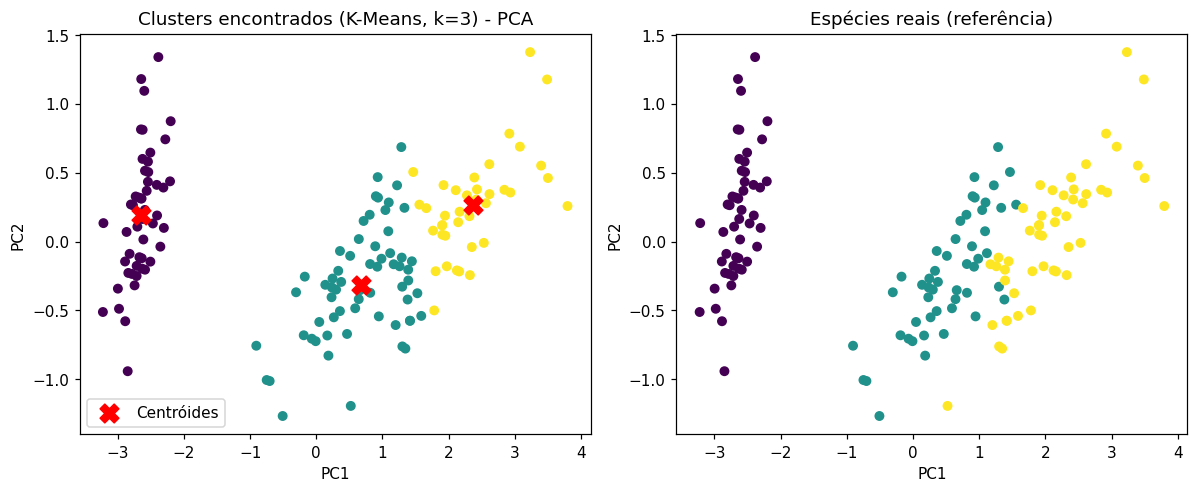

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_viz, cmap='viridis', s=30)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=150, label='Centróides')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Clusters encontrados (K-Means, k=3) - PCA")
axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=30)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Espécies reais (referência)")

plt.tight_layout()
plt.show()


A mesma comparação, agora usando diretamente dois atributos originais
(comprimento e largura da pétala), sem redução de dimensionalidade — como são
os atributos mais discriminativos da base, o resultado é bem parecido com o
da projeção PCA.

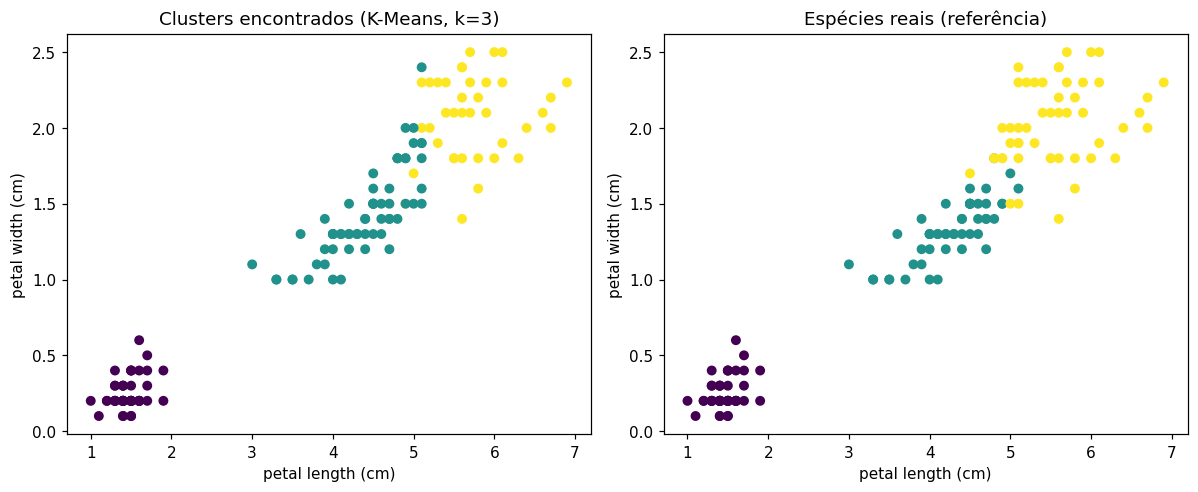

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

axes[0].scatter(X[:, 2], X[:, 3], c=labels_viz, cmap='viridis', s=30)
axes[0].set_xlabel(feat_names[2]); axes[0].set_ylabel(feat_names[3])
axes[0].set_title("Clusters encontrados (K-Means, k=3)")

axes[1].scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', s=30)
axes[1].set_xlabel(feat_names[2]); axes[1].set_ylabel(feat_names[3])
axes[1].set_title("Espécies reais (referência)")

plt.tight_layout()
plt.show()


**Leitura da matriz de contingência:** o cluster correspondente a
*setosa* é perfeito (50/50). O maior "erro" está entre *versicolor* e
*virginica*: como essas duas espécies têm sobreposição real nos atributos de
pétala/sépala, uma parte das amostras de *virginica* acaba agrupada junto
com *versicolor*. Isso não é uma falha do algoritmo — é uma limitação
esperada quando os grupos reais não são perfeitamente separáveis no espaço
de atributos usado.

## 8. Efeito da normalização - comparação final

Repetimos o K-Means com **k=3** nos dados **padronizados** e comparamos
diretamente com o resultado dos dados brutos (Seção 7).

In [14]:
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

wcss_scaled_final = kmeans_scaled.inertia_
sil_scaled_final = silhouette_score(X_scaled, labels_scaled)
ari_scaled = adjusted_rand_score(y, labels_scaled)

comparacao_norm = pd.DataFrame({
    'Versão dos dados': ['Brutos', 'Padronizados'],
    'WCSS': [wcss_final, wcss_scaled_final],
    'Silhouette Score': [sil_final, sil_scaled_final],
    'ARI vs. espécie real': [ari, ari_scaled],
})
comparacao_norm


,Versão dos dados,WCSS,Silhouette Score,ARI vs. espécie real
0,Brutos,78.851441,0.552819,0.730238
1,Padronizados,139.820496,0.459948,0.620135


**Resultado, à primeira vista, contraintuitivo:** neste caso específico,
padronizar os atributos **piorou** a concordância com as espécies reais (ARI
caiu de ≈0,73 para ≈0,62) e reduziu o Silhouette Score. Isso acontece porque,
na base Iris, os atributos de **pétala** (que têm naturalmente maior
variância nos dados brutos) são também os **mais discriminativos** entre as
espécies. Ao padronizar, a **largura da sépala** — pouco discriminativa e
bastante sobreposta entre espécies — passa a ter o mesmo peso que os
atributos de pétala, "diluindo" o sinal mais útil para separar os grupos.

Isso não invalida a prática de padronizar: em bases onde os atributos estão
em **unidades diferentes** (ex.: idade em anos e salário em milhares), a
padronização costuma ser essencial. A lição aqui é que a padronização é uma
boa prática **geral**, mas seu efeito deve sempre ser conferido caso a caso —
quando a diferença de escala dos atributos brutos está correlacionada com a
relevância deles para o agrupamento, padronizar pode remover informação
útil.

## 9. Análise e Conclusão

**Influência do valor de K:** valores pequenos de K (2-3) produzem os
agrupamentos mais coerentes e mais bem separados nesta base. K=2 isola a
espécie *setosa* do restante; K=3 aproxima-se bem da estrutura real de 3
espécies. A partir de K=4, os clusters adicionais fragmentam artificialmente
uma região naturalmente contínua (*versicolor*/*virginica*), sem ganho real
de interpretabilidade — um sintoma clássico de "over-clustering".

**Método do Cotovelo e Silhouette Score:** as duas métricas concordam entre
si e reforçam a mesma conclusão: o cotovelo aparece entre k=2 e k=3, e o
Silhouette é máximo em k=2, com k=3 logo atrás. Como o Silhouette avalia
apenas compacidade/separação geométrica (sem "saber" que existem 3 espécies
biológicas), ele naturalmente favorece k=2, onde a separação geométrica é
mais nítida. Isso mostra uma limitação prática dessas métricas: elas indicam
bons candidatos a K, mas a escolha final também deve considerar o
conhecimento de domínio disponível.

**Efeito da normalização:** ao contrário do que normalmente se espera,
padronizar os atributos piorou a qualidade do agrupamento nesta base
específica (Seção 8), pois reduziu a influência dos atributos de pétala, que
são os mais informativos para separar as espécies. Isso reforça que a
padronização deve ser uma escolha analisada, não aplicada automaticamente.

**Características dos grupos encontrados:** o cluster de *setosa* é
perfeitamente isolado e facilmente identificável — é a espécie com pétalas
visivelmente menores. Já *versicolor* e *virginica* formam grupos com alguma
sobreposição, refletindo a semelhança morfológica real entre elas; uma
pequena parcela de amostras de *virginica* é agrupada junto de *versicolor*.

**Limitações do K-Means:** o algoritmo exige que o número de clusters (K)
seja definido previamente; assume implicitamente clusters de formato
aproximadamente esférico/convexo e tamanho semelhante, o que pode não
refletir a real distribuição dos dados; é sensível à escala dos atributos
(Seção 8) e à inicialização dos centróides (mitigado aqui pelo uso de
`n_init=10`); e, por ser um algoritmo de atribuição "dura" (cada ponto
pertence a exatamente um cluster), não modela bem a incerteza em regiões de
sobreposição entre grupos reais, como ocorre entre *versicolor* e
*virginica*.